In [209]:
%cd /home/plent/Documenten/Gitlab/Coumaric_Acid_V2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from scipy.stats import entropy
from scipy.stats import truncnorm

/home/plent/Documenten/Gitlab/Coumaric_Acid_V2


In [216]:
betas = np.linspace(0,32, 50,dtype=int)
states  = np.linspace(100, 10000,20,dtype=int)

# alphas= np.linspace(0,1,20,dtype=int)

entropies = []

df = np.zeros(shape=(len(betas),len(states)))

state_dependency = np.zeros(shape=(len(states),len(betas)))
for i, state in enumerate(states):
    for k, beta in enumerate(betas):
        x = truncnorm.rvs(0.5,2,loc=1, size=state)
        prob = softmax(x*beta)

        entropy_x = entropy(prob)
        state_dependency[i,k]=entropy_x



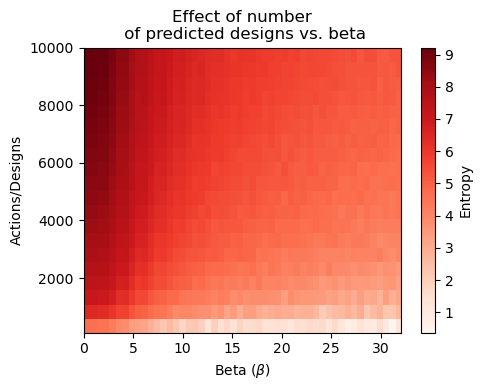

In [217]:
fig, ax = plt.subplots(figsize=(5,4))

im = ax.imshow(
    state_dependency,
    cmap='Reds',
    aspect='auto',
    extent=[betas.min(), betas.max(), states.min(), states.max()],
    origin='lower'
)

ax.set_xlabel('Beta $(\\beta)$')
ax.set_ylabel('Actions/Designs')
ax.set_title("Effect of number\n of predicted designs vs. beta")
fig.tight_layout()

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Entropy')

# fig.savefig("figures/figures_revision/nstates_vs_beta.png")
# fig.savefig("figures/figures_revision/nstates_vs_beta.svg")

In [212]:
betas = np.linspace(0,10, 50,dtype=int)
# states  = np.linspace(100, 10000,20,dtype=int)

variances = np.linspace(0.5,4,20)

entropies = []

df = np.zeros(shape=(len(betas),len(states)))

state_dependency = np.zeros(shape=(len(states),len(betas)))
for i, variance in enumerate(variances):
    for k, beta in enumerate(betas):
        x = truncnorm.rvs(0.5,2,loc=1,scale=variance, size=50000)
        prob = softmax(x*beta)

        entropy_x = entropy(prob)
        state_dependency[i,k]=entropy_x


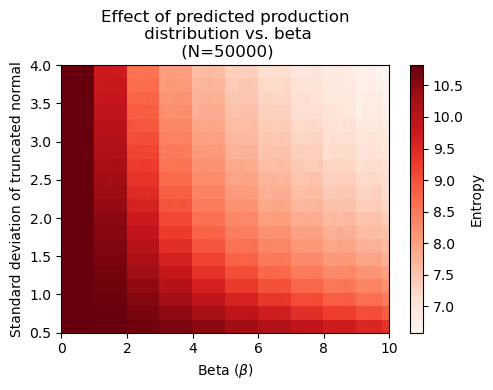

In [213]:
fig, ax = plt.subplots(figsize=(5,4))

im = ax.imshow(
    state_dependency,
    cmap='Reds',
    aspect='auto',
    extent=[betas.min(), betas.max(), variances.min(), variances.max()],
    origin='lower'
)

ax.set_xlabel('Beta $(\\beta)$')
ax.set_ylabel('Standard deviation of truncated normal')
ax.set_title("Effect of predicted production\n distribution vs. beta\n (N=50000)")
fig.tight_layout()

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Entropy')
fig.savefig("figures/figures_revision/standard_dev_vs_beta.png")
fig.savefig("figures/figures_revision/standard_dev_vs_beta.svg")